# 01 — QC metrics and filtering, across all 8 donors

In notebook 00 we looked at counts-per-nucleus and genes-per-nucleus for a
single donor, informally. Here we do it properly: compute standard QC
metrics with `scanpy`'s built-in function, look at them across **all 8
donors** (batch effects in QC itself are common and worth seeing early),
and choose + apply filtering thresholds.

## The three QC metrics we'll use

1. **`total_counts`** — total UMI counts per nucleus (same as notebook 00).
   Very low values usually mean an empty droplet or a degraded/dying
   nucleus that leaked most of its RNA; unusually high values can mean two
   nuclei captured together (a **doublet**, see below).
2. **`n_genes_by_counts`** — number of distinct genes detected per nucleus.
   Correlates with `total_counts` but captures a different failure mode:
   a nucleus with counts concentrated in very few genes is suspicious even
   if its total count looks fine.
3. **`pct_counts_mt`** — percent of counts coming from mitochondrial genes
   (symbols starting with `MT-`). In *whole-cell* scRNA-seq this is a
   classic marker of cell stress/death (dying cells leak cytoplasmic mRNA
   but their mitochondria — and mitochondrial transcripts — are relatively
   protected). In *single-nucleus* data like this dataset, mitochondria are
   physically excluded from the nucleus, so we expect this number to be
   tiny across the board (a fraction of a percent) — a high value here is a
   strong signal of cytoplasmic contamination, not normal biology.

scanpy computes all of this in one call: `sc.pp.calculate_qc_metrics`.

## What's a doublet?

A **doublet** (or multiplet) is a single droplet/barcode that accidentally
captured *two or more* nuclei instead of one. It shows up in the data as a
single "cell" whose transcriptome looks like a mix of two different cell
types (e.g. part excitatory neuron, part microglia) — which can create
fake intermediate clusters or fake "hybrid" cell types if not handled.
Detecting doublets properly usually needs a dedicated tool (e.g. Scrublet,
DoubletFinder) that simulates artificial doublets and asks how similar each
real nucleus's neighborhood is to them. SEA-AD already ran that step for us
and stored the result in `obs["Doublet score"]` — we'll use their score
rather than re-deriving it, exactly as the companion R/Seurat project does.

In [1]:
import warnings
import gc

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
RNA_DIR = f"{DATA_DIR}/rna"

DONOR_IDS = [
    "H20.33.001", "H20.33.002", "H20.33.004", "H20.33.005",
    "H20.33.012", "H20.33.013", "H20.33.017", "H21.33.003",
]

## Computing QC metrics for all 8 donors

We load one donor at a time, compute QC metrics on its raw counts
(`layers["UMIs"]`), keep only the resulting per-nucleus QC table (a small
DataFrame), then discard the full AnnData object before moving to the next
donor. This keeps peak memory to roughly "one donor's full h5ad" rather
than "all 8 donors at once" — a sensible habit on a shared machine, and
generally good practice once datasets get larger than your RAM.

In [2]:
qc_frames = []

for donor in DONOR_IDS:
    a = sc.read_h5ad(f"{RNA_DIR}/{donor}_RNAseq_final-nuclei.h5ad")

    # Work from raw UMI counts, not the pre-normalized .X (see notebook 00).
    a.X = a.layers["UMIs"].copy()

    # Flag mitochondrial genes by gene symbol prefix — scanpy convention.
    a.var["mt"] = a.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(
        a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
    )

    qc = a.obs[
        ["total_counts", "n_genes_by_counts", "pct_counts_mt",
         "Doublet score", "Fraction mitochondrial UMIs", "method", "Class", "Subclass"]
    ].copy()
    qc["donor"] = donor
    qc_frames.append(qc)

    print(f"{donor}: {a.n_obs:,} nuclei loaded and QC'd")

    del a
    gc.collect()

qc_all = pd.concat(qc_frames, axis=0)
print(f"\nTotal nuclei across all 8 donors (pre-filtering): {qc_all.shape[0]:,}")

H20.33.001: 19,297 nuclei loaded and QC'd


H20.33.002: 20,040 nuclei loaded and QC'd


H20.33.004: 20,411 nuclei loaded and QC'd


H20.33.005: 25,872 nuclei loaded and QC'd


H20.33.012: 16,719 nuclei loaded and QC'd


H20.33.013: 18,261 nuclei loaded and QC'd


H20.33.017: 14,694 nuclei loaded and QC'd


H21.33.003: 18,913 nuclei loaded and QC'd

Total nuclei across all 8 donors (pre-filtering): 154,207


Sanity check: our own `pct_counts_mt` (computed from raw counts, on a 0-100
scale) vs. SEA-AD's own `Fraction mitochondrial UMIs` (on a 0-1 scale) —
these should agree once you account for the scale.

In [3]:
correlation = np.corrcoef(
    qc_all["pct_counts_mt"] / 100, qc_all["Fraction mitochondrial UMIs"]
)[0, 1]
print(f"Correlation between our pct_counts_mt/100 and SEA-AD's Fraction mitochondrial UMIs: {correlation:.4f}")
qc_all[["pct_counts_mt", "Fraction mitochondrial UMIs"]].describe()

Correlation between our pct_counts_mt/100 and SEA-AD's Fraction mitochondrial UMIs: 1.0000


,pct_counts_mt,Fraction mitochondrial UMIs
count,154207.000000,154207.000000
mean,0.352965,0.003530
std,0.513381,0.005134
min,0.000000,0.000000
25%,0.069928,0.000699
50%,0.177162,0.001772
75%,0.414108,0.004141
max,4.998906,0.049989


## Visualizing QC metrics across donors

This is the important step: look at distributions **per donor**, not just
pooled, because a threshold that's reasonable for one donor's sequencing
depth might discard almost everything from another.

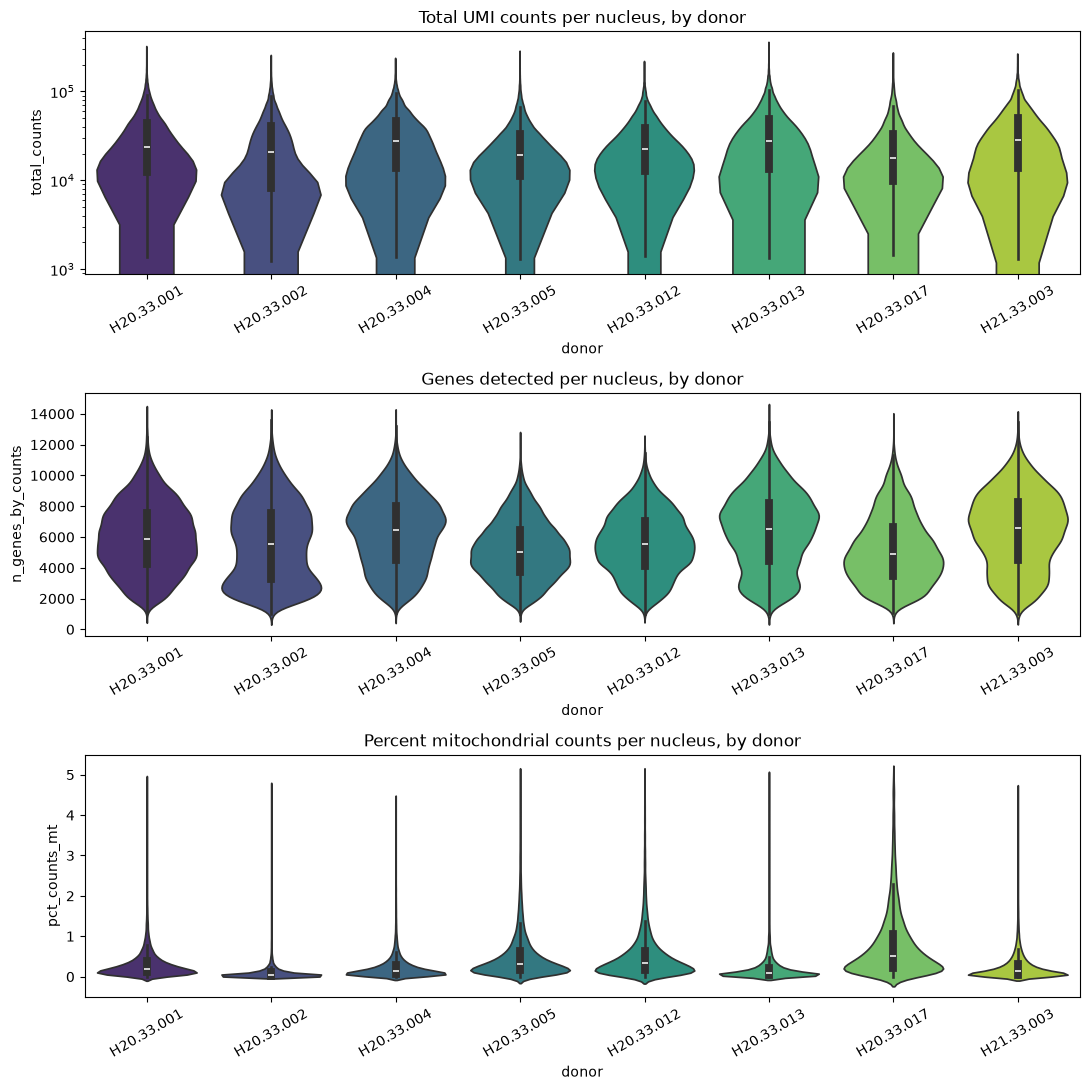

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)

sns.violinplot(data=qc_all, x="donor", y="total_counts", ax=axes[0], hue="donor", legend=False, palette="viridis")
axes[0].set_yscale("log")
axes[0].set_title("Total UMI counts per nucleus, by donor")
axes[0].tick_params(axis="x", rotation=30)

sns.violinplot(data=qc_all, x="donor", y="n_genes_by_counts", ax=axes[1], hue="donor", legend=False, palette="viridis")
axes[1].set_title("Genes detected per nucleus, by donor")
axes[1].tick_params(axis="x", rotation=30)

sns.violinplot(data=qc_all, x="donor", y="pct_counts_mt", ax=axes[2], hue="donor", legend=False, palette="viridis")
axes[2].set_title("Percent mitochondrial counts per nucleus, by donor")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Note how low `pct_counts_mt` is across the board (typically well under 1%)
— consistent with these being nuclei, not whole cells, as explained above.
Also note some visible donor-to-donor differences in sequencing depth
(`total_counts`) — this is exactly the kind of technical, donor-specific
variation that will resurface as a "batch effect" in notebook 02.

In [5]:
qc_all.groupby("donor")[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median().round(2)

,total_counts,n_genes_by_counts,pct_counts_mt
donor,,,
H20.33.001,23900.0,5859.0,0.20
H20.33.002,20778.0,5518.0,0.05
H20.33.004,27485.0,6440.0,0.14
H20.33.005,19385.5,5026.0,0.31
H20.33.012,22710.0,5524.0,0.33
H20.33.013,27864.0,6549.0,0.10
H20.33.017,17881.5,4873.5,0.51
H21.33.003,28434.0,6583.0,0.13


## SEA-AD's doublet score

`Doublet score` ranges roughly 0-1 in principle, higher = more
doublet-like. Let's look at its distribution and how it correlates with
total counts (doublets are, on average, higher-count nuclei — makes sense,
since they contain RNA from two nuclei).

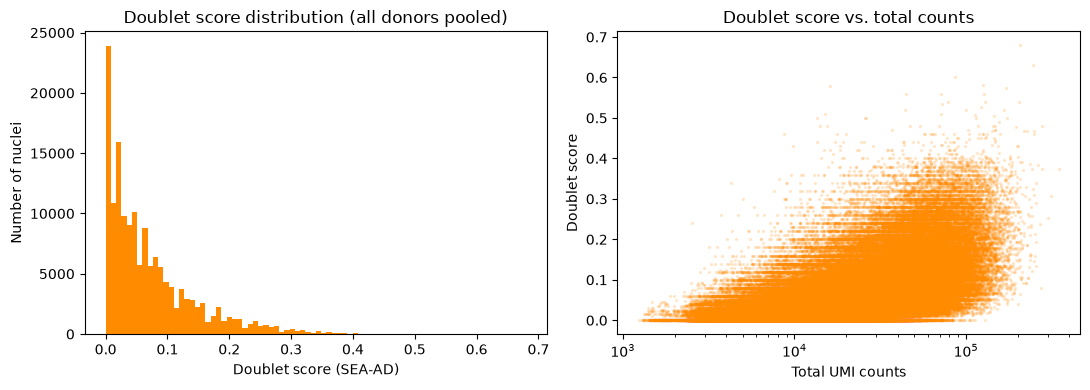

count    154207.000000
mean          0.071672
std           0.073155
min           0.000000
25%           0.020000
50%           0.050000
75%           0.100000
max           0.680000
Name: Doublet score, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(qc_all["Doublet score"], bins=80, color="darkorange")
axes[0].set_xlabel("Doublet score (SEA-AD)")
axes[0].set_ylabel("Number of nuclei")
axes[0].set_title("Doublet score distribution (all donors pooled)")

axes[1].scatter(qc_all["total_counts"], qc_all["Doublet score"], s=2, alpha=0.15, color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("Total UMI counts")
axes[1].set_ylabel("Doublet score")
axes[1].set_title("Doublet score vs. total counts")

plt.tight_layout()
plt.show()

print(qc_all["Doublet score"].describe())

## Choosing filtering thresholds

There's no universally "correct" threshold — you choose values that trim
the clear low-quality tail without discarding a large fraction of otherwise
reasonable nuclei, then sanity-check what fraction you're removing. We'll
use thresholds broadly consistent with the companion R/Seurat project's
approach (same dataset, same reasoning) so results stay comparable:

- **`total_counts >= 500`** — drop near-empty droplets / degraded nuclei
- **`n_genes_by_counts >= 250`** — drop nuclei with too little transcriptomic
  complexity to be informative
- **`pct_counts_mt <= 5`** — generous given how low these values run in
  snRNA-seq; this mainly catches rare cytoplasmic-contamination outliers
- **`Doublet score <= 0.3`** — drop nuclei SEA-AD's own doublet caller
  flagged as likely multiplets (their score distribution above has a long
  tail beyond ~0.3 that lines up with the high-count nuclei on the right of
  the scatter plot)

These are deliberately conservative (permissive) thresholds — the point of
this series is to teach the workflow, not to squeeze out maximal
stringency. In a real project you'd iterate on these after seeing how
clustering behaves.

In [7]:
MIN_COUNTS = 500
MIN_GENES = 250
MAX_PCT_MT = 5.0
MAX_DOUBLET = 0.3

pass_filter = (
    (qc_all["total_counts"] >= MIN_COUNTS)
    & (qc_all["n_genes_by_counts"] >= MIN_GENES)
    & (qc_all["pct_counts_mt"] <= MAX_PCT_MT)
    & (qc_all["Doublet score"] <= MAX_DOUBLET)
)

print(f"Nuclei before filtering: {qc_all.shape[0]:,}")
print(f"Nuclei after filtering:  {pass_filter.sum():,}")
print(f"Fraction retained:       {pass_filter.mean():.1%}")

Nuclei before filtering: 154,207
Nuclei after filtering:  152,212
Fraction retained:       98.7%


Break the retained fraction down per donor and per filter criterion, to
make sure no single donor is being disproportionately discarded (which
would bias downstream comparisons — especially relevant later, since
notebook 04 compares donors by AD pathology group).

In [8]:
per_donor = qc_all.groupby("donor").apply(
    lambda d: pd.Series({
        "n_total": len(d),
        "n_pass": (
            (d["total_counts"] >= MIN_COUNTS)
            & (d["n_genes_by_counts"] >= MIN_GENES)
            & (d["pct_counts_mt"] <= MAX_PCT_MT)
            & (d["Doublet score"] <= MAX_DOUBLET)
        ).sum(),
    }),
    include_groups=False,
)
per_donor["pct_retained"] = (per_donor["n_pass"] / per_donor["n_total"] * 100).round(1)
per_donor

,n_total,n_pass,pct_retained
donor,,,
H20.33.001,19297,19160,99.3
H20.33.002,20040,19548,97.5
H20.33.004,20411,20297,99.4
H20.33.005,25872,25425,98.3
H20.33.012,16719,16357,97.8
H20.33.013,18261,18149,99.4
H20.33.017,14694,14420,98.1
H21.33.003,18913,18856,99.7


## Before / after: visualizing the effect of filtering

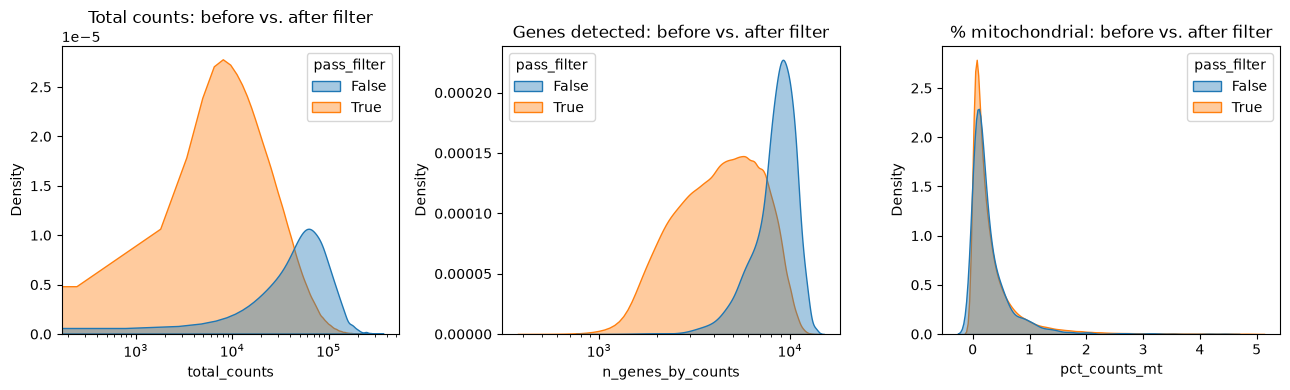

In [9]:
qc_all["pass_filter"] = pass_filter

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    ["Total counts", "Genes detected", "% mitochondrial"],
):
    sns.kdeplot(data=qc_all, x=col, hue="pass_filter", ax=ax, common_norm=False, fill=True, alpha=0.4)
    if col != "pct_counts_mt":
        ax.set_xscale("log")
    ax.set_title(f"{title}: before vs. after filter")

plt.tight_layout()
plt.show()

Filtering cleanly removes the low-count / low-complexity shoulder of the
distribution while leaving the bulk of the data untouched — a good sign
that thresholds are in a sensible place rather than cutting into the main
population.

We keep `qc_all` (with the `pass_filter` column) around conceptually here;
in the next notebook we'll re-load each donor, apply this same filter
directly to the AnnData objects (`adata = adata[adata.obs["total_counts"]
>= MIN_COUNTS]` etc., or equivalently `sc.pp.filter_cells`/
`sc.pp.filter_genes`), and concatenate all 8 donors into one combined
object for clustering.

## Recap

- `sc.pp.calculate_qc_metrics` computes standard per-nucleus QC metrics in
  one call, once you flag mitochondrial genes via `.var["mt"]`.
- Always look at QC distributions **per donor/sample**, not just pooled —
  depth and quality vary by donor.
- `pct_counts_mt` runs very low here because this is single-**nucleus**,
  not single-cell, data — mitochondria aren't in the nucleus.
- We used SEA-AD's precomputed `Doublet score` rather than running our own
  doublet detector, which is a reasonable simplification when good
  reference annotations already exist.
- Filtering at `total_counts>=500`, `n_genes_by_counts>=250`,
  `pct_counts_mt<=5`, `Doublet score<=0.3` retains the great majority of
  nuclei fairly evenly across donors.

Next: **02_normalize_cluster_umap.ipynb** — normalization, HVGs, PCA, the
donor batch-effect problem, and Leiden clustering + UMAP.

## Homework

1. **Tighten the mitochondrial threshold.** Re-run the filtering step with
   `MAX_PCT_MT = 1.0` instead of 5.0. How many nuclei do you lose overall,
   and is the loss even across donors or concentrated in a few?

2. **Write the code yourself:** compute, per donor, the *median* `Doublet
   score` and the *fraction* of nuclei with `Doublet score > 0.3`. Do any
   donors stand out?

3. **Interpretation.** Two donors in this cohort have especially high
   `total_counts` medians and two have especially low ones (look at the
   `per_donor`-style table you can build with `.groupby("donor")`). Given
   that all 8 donors went through the same wet-lab protocol, what are some
   plausible technical (non-biological) reasons donors might differ in
   sequencing depth?

4. **Modify the plot:** redo the "before vs. after" KDE plot for
   `n_genes_by_counts` only, but facet it by donor (`col="donor"` in a
   `sns.displot` or a manual loop over donors with subplots) instead of
   pooling all donors together. Does filtering behave consistently across
   donors?

In [10]:
# Q1 — your code here

In [11]:
# Q2 — your code here

Q3 — your answer here

In [12]:
# Q4 — your code here